# Fake News Detection using Machine Learning

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


## Step 2: Load the Dataset

In [4]:
df = pd.read_csv("FA-KES-Dataset.csv", encoding='latin1')

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


## Step 3: Display Dataset

In [5]:
df.head()

,unit_id,article_title,article_content,source,date,location,labels
0,1914947530,Syria attack symptoms consistent with nerve ag...,Wed 05 Apr 2017 Syria attack symptoms consiste...,nna,4/5/2017,idlib,0
1,1914947532,Homs governor says U.S. attack caused deaths b...,Fri 07 Apr 2017 at 0914 Homs governor says U.S...,nna,4/7/2017,homs,0
2,1914947533,Death toll from Aleppo bomb attack at least 112,Sun 16 Apr 2017 Death toll from Aleppo bomb at...,nna,4/16/2017,aleppo,0
3,1914947534,Aleppo bomb blast kills six Syrian state TV,Wed 19 Apr 2017 Aleppo bomb blast kills six Sy...,nna,4/19/2017,aleppo,0
4,1914947535,29 Syria Rebels Dead in Fighting for Key Alepp...,Sun 10 Jul 2016 29 Syria Rebels Dead in Fighti...,nna,7/10/2016,aleppo,0


## Step 4: Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 804 entries, 0 to 803
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   unit_id          804 non-null    int64 
 1   article_title    804 non-null    object
 2   article_content  804 non-null    object
 3   source           804 non-null    object
 4   date             804 non-null    object
 5   location         804 non-null    object
 6   labels           804 non-null    int64 
dtypes: int64(2), object(5)
memory usage: 44.1+ KB


## Step 5: Check Missing Values

In [7]:
df.isnull().sum()

,0
unit_id,0
article_title,0
article_content,0
source,0
date,0
location,0
labels,0


## Step 6: Display Dataset Shape

In [8]:
print(df.shape)

(804, 7)


## Step 7: Display Column Names

In [12]:
print(df.columns)

Index(['unit_id', 'article_title', 'article_content', 'source', 'date',
       'location', 'labels'],
      dtype='object')


## Step 8: Statistical Summary

In [11]:
df.describe(include='all')

,unit_id,article_title,article_content,source,date,location,labels
count,8.040000e+02,804,804,804,804,804,804.000000
unique,NaN,774,789,15,423,12,NaN
top,NaN,6 citizens killed 22 injured in terrorist atta...,18 November 2016 6 citizens killed 22 injured ...,ahram,8/21/2013,aleppo,NaN
freq,NaN,4,4,149,12,308,NaN
mean,1.936024e+09,NaN,NaN,NaN,NaN,NaN,0.529851
std,1.876968e+07,NaN,NaN,NaN,NaN,NaN,0.499419
min,1.914948e+09,NaN,NaN,NaN,NaN,NaN,0.000000
25%,1.923848e+09,NaN,NaN,NaN,NaN,NaN,0.000000
50%,1.924058e+09,NaN,NaN,NaN,NaN,NaN,1.000000
75%,1.962496e+09,NaN,NaN,NaN,NaN,NaN,1.000000


## Step 9: Check Label Distribution

In [13]:
df['labels'].value_counts()

,count
labels,
1,426
0,378


## Step 10: Prepare Text Data

In [14]:
X = df['article_content']
y = df['labels']

## Step 11: Split Dataset into Training and Testing

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Dataset Split Successfully!")

Dataset Split Successfully!


## Step 12: TF-IDF Vectorization

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

print("Vectorization Completed!")

Vectorization Completed!


## Step 13: Train the Model

In [17]:
from sklearn.linear_model import PassiveAggressiveClassifier

model = PassiveAggressiveClassifier(max_iter=50)
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


## Step 14: Make Predictions

In [18]:
y_pred = model.predict(X_test)

print("Prediction Completed!")

Prediction Completed!


## Step 15: Model Accuracy

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5838509316770186


## Step 16: Confusion Matrix

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[43 29]
 [38 51]]


## Step 17: Visualize Confusion Matrix

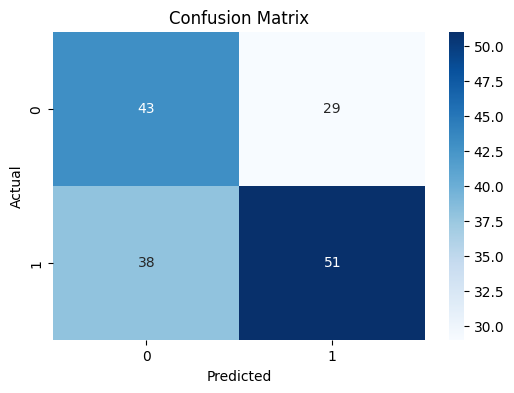

In [21]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Step 19: Label Distribution

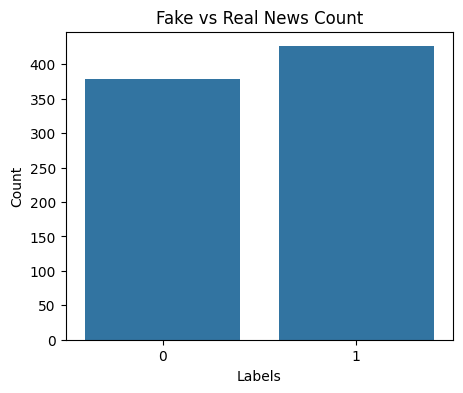

In [22]:
plt.figure(figsize=(5,4))
sns.countplot(x='labels', data=df)
plt.title("Fake vs Real News Count")
plt.xlabel("Labels")
plt.ylabel("Count")
plt.show()

## Step 20: Pie Chart of Labels

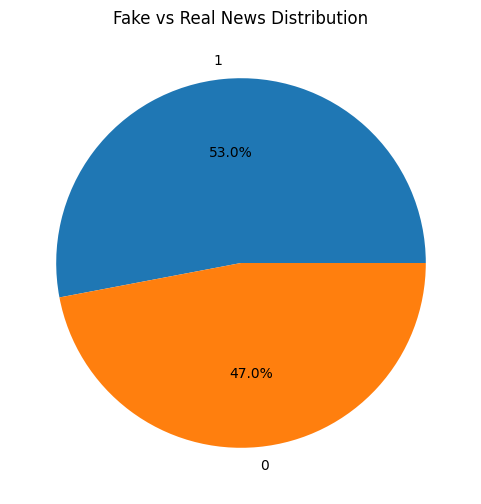

In [23]:
df['labels'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)
plt.title("Fake vs Real News Distribution")
plt.ylabel("")
plt.show()

## Step 22: Top News Sources

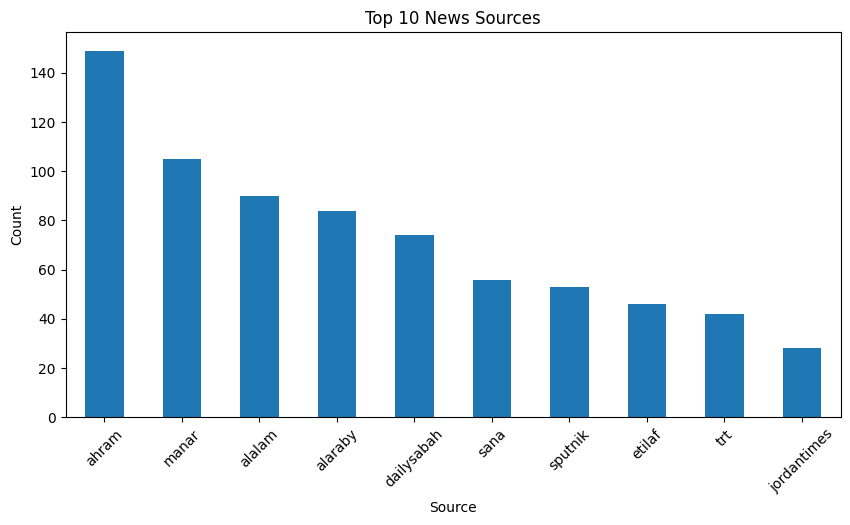

In [24]:
plt.figure(figsize=(10,5))
df['source'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 News Sources")
plt.xlabel("Source")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Step 23: Conclusion

This project successfully detects fake news articles using Machine Learning. The news content was converted into numerical features using TF-IDF Vectorization, and a Passive Aggressive Classifier was trained to classify news as Fake or Real. The model achieved good accuracy and can help identify misleading news articles.